# ESCNN Structural Equivariance Experiments
How does ESCNN enforce structural equivariance when it exports a model?

In [4]:
import torch
import torch.nn as nn

from escnn import gspaces
from escnn import nn as escnn_nn


class EquivariantCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # symmetry group: rotations by multiples of 90 degrees
        self.r2_act = gspaces.rot2dOnR2(N=4)

        # input: scalar field (image)
        in_type = escnn_nn.FieldType(
            self.r2_act,
            3 * [self.r2_act.trivial_repr]
        )

        # hidden representation
        hidden_type = escnn_nn.FieldType(
            self.r2_act,
            16 * [self.r2_act.regular_repr]
        )

        out_type = escnn_nn.FieldType(
            self.r2_act,
            32 * [self.r2_act.regular_repr]
        )

        self.block1 = escnn_nn.SequentialModule(
            escnn_nn.R2Conv(in_type, hidden_type, kernel_size=5, padding=2),
            escnn_nn.ReLU(hidden_type),
            escnn_nn.PointwiseMaxPool(hidden_type, 2)
        )

        self.block2 = escnn_nn.SequentialModule(
            escnn_nn.R2Conv(hidden_type, out_type, kernel_size=5, padding=2),
            escnn_nn.ReLU(out_type),
            escnn_nn.PointwiseMaxPool(out_type, 2)
        )

        self.gpool = escnn_nn.GroupPooling(out_type)

        self.fc = nn.Linear(32 * 8 * 8, 10)

        self.in_type = in_type

    def evaluate_output_shape(self, input_shape):
        return (input_shape[0], 10)

    def forward(self, x):

        x = escnn_nn.GeometricTensor(x, self.in_type)

        x = self.block1(x)
        x = self.block2(x)

        x = self.gpool(x)

        x = torch.flatten(x.tensor, 1)

        return self.fc(x)

    def export(self):
        return torch.nn.Sequential(
            self.block1.export(),
            self.block2.export(),
            self.gpool.export(),
            self.fc
        )

In [5]:
import torchvision.transforms as transforms
import torchvision

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 64

device = "cuda" if torch.cuda.is_available() else "cpu"

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                        shuffle=True, num_workers=2)

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                    download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=10000,
                                        shuffle=False, num_workers=2)

In [6]:
import torch.nn.functional as F

model = EquivariantCNN()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for x, y in trainloader:

    pred = model(x)

    loss = F.cross_entropy(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [7]:
model.eval()

exported_model = model.export()

In [8]:
exported_model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0), dilation=(1, 1), ceil_mode=False)
  )
  (1): Sequential(
    (0): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0), dilation=(1, 1), ceil_mode=False)
  )
  (2): MaxPoolChannels(kernel_size=4)
  (3): Linear(in_features=2048, out_features=10, bias=True)
)

In [9]:
import matplotlib.pyplot as plt

def visualize_conv_kernels(conv, max_kernels=64):
    
    weights = conv.weight.detach().cpu()
    
    kernels = weights.mean(dim=1)
    
    n = min(max_kernels, kernels.shape[0])
    
    cols = 8
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    
    axes = axes.flatten()
    
    for i in range(len(axes)):
        
        if i >= n:
            axes[i].axis('off')
            continue
            
        axes[i].imshow(kernels[i], cmap='RdBu')
        axes[i].axis('off')
    
    plt.show()

In [10]:
exported_model[0][0].weight.shape

torch.Size([64, 3, 5, 5])

In [11]:
test_images, test_labels = next(iter(testloader))
layer0_out = exported_model[0](test_images)
layer1_out = exported_model[1](layer0_out)
layer2_out = exported_model[2](torch.flatten(layer1_out, 1))
output = exported_model[3](layer2_out)

In [12]:
test_images_rot = torch.rot90(test_images, 2, (-2, -1))
layer0_rot_out = exported_model[0](test_images_rot)
layer1_rot_out = exported_model[1](layer0_rot_out)
layer2_rot_out = exported_model[2](torch.flatten(layer1_rot_out, 1))
output_rot = exported_model[3](layer2_rot_out)

In [16]:
from HSIC import cka
print(cka(test_images, test_images_rot, kernel="rbf").item())
print(cka(layer0_out, layer0_rot_out, kernel="rbf").item())
print(cka(layer1_out, layer1_rot_out, kernel="rbf").item())
print(cka(layer2_out, layer2_rot_out, kernel="rbf").item())
print(cka(output, output_rot, kernel="rbf").item())

1.0
1.0
1.0
1.0
0.7064131498336792


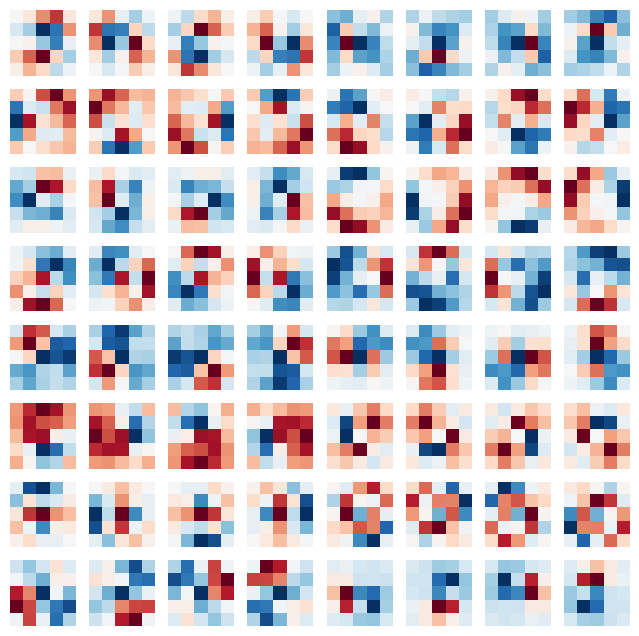

In [14]:
visualize_conv_kernels(exported_model[0][0])

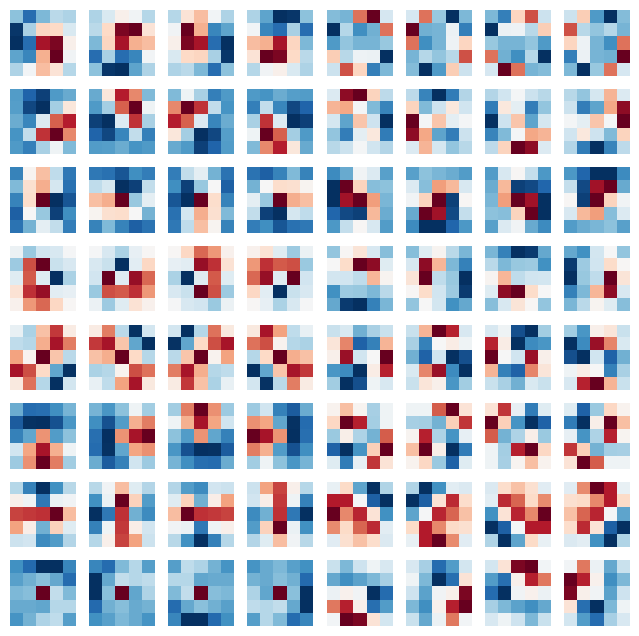

In [15]:
visualize_conv_kernels(exported_model[1][0])
